# Lunar Seismic Event Classification
**Shivani Hebbar | 2548330 | 3 MDS A**

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.dummy            import DummyClassifier
from sklearn.linear_model     import LogisticRegression, LinearRegression
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing    import StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.model_selection  import (TimeSeriesSplit, GridSearchCV,
                                       cross_validate, learning_curve)
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                       f1_score, roc_auc_score, confusion_matrix,
                                       classification_report, roc_curve, auc)

## 1. Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\lunar_seismic_ml_ready.csv")
print("Shape:", df.shape)
df.head()

Shape: (13057, 108)


,target_label,target_hazardous,event_type,event_type_label,mq_class,year_full,day_of_year,date,start_time,stop_time,...,15LPZ,16SPZ,16LPX,16LPY,16LPZ,grade,comments,traces,event_type_2004,mq_class_2004
0,1.0,1,M,Deep Moonquake (unclassified),NaN,1969,208,1969-07-27,2348,40.0,...,NaN,NaN,NaN,NaN,NaN,NaN,11Z AMLPITUDE,NaN,M,NaN
1,2.0,0,C,Meteoroid Impact,NaN,1969,209,1969-07-28,1146,1215.0,...,NaN,NaN,NaN,NaN,NaN,NaN,11Z AMPLITUDE,NaN,C,NaN
2,0.0,1,A,Deep Moonquake (classified),0.0,1969,209,1969-07-28,1349,1430.0,...,NaN,NaN,NaN,NaN,NaN,NaN,11Z AMPLITUDE SP,NaN,A,0.0
3,2.0,0,C,Meteoroid Impact,NaN,1969,210,1969-07-29,1318,1415.0,...,NaN,NaN,NaN,NaN,NaN,NaN,11Z AMPLITUDE,NaN,C,NaN
4,2.0,0,C,Meteoroid Impact,NaN,1969,214,1969-08-02,1720,1810.0,...,NaN,NaN,NaN,NaN,NaN,NaN,11Z AMPLITUDE,NaN,C,NaN


## 2. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13057 entries, 0 to 13056
Columns: 108 entries, target_label to mq_class_2004
dtypes: float64(85), int64(17), object(6)
memory usage: 10.8+ MB


In [4]:
df.describe().round(3)

,target_label,target_hazardous,mq_class,year_full,day_of_year,start_time,stop_time,start_hour,duration_min,event_continues,...,15SPZ,15LPX,15LPY,15LPZ,16SPZ,16LPX,16LPY,16LPZ,traces,mq_class_2004
count,5215.000,13057.000,1360.000,13057.000,13057.000,13057.000,12555.000,13057.000,11667.000,13057.000,...,717.0,1856.0,2391.0,819.0,312.0,3215.0,3322.0,1041.0,8404.000,7348.000
mean,1.278,0.243,29.262,1973.405,185.828,1166.368,1790.478,11.859,28.976,0.068,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.761,137.963
std,1.118,0.429,28.196,2.127,100.765,690.675,2360.866,6.912,16.000,0.252,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.487,148.007
min,0.000,0.000,0.000,1969.000,1.000,0.000,0.000,0.000,1.000,0.000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000,0.000
25%,0.000,0.000,8.000,1972.000,105.000,556.000,620.000,5.930,20.000,0.000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.000,15.000
50%,1.000,0.000,20.000,1973.000,183.000,1142.000,1235.000,11.700,26.000,0.000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.000,57.000
75%,2.000,0.000,40.000,1975.000,270.000,1745.000,1910.000,17.750,34.000,0.000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.000,242.000
max,7.000,1.000,114.000,1977.000,366.000,2359.000,9999.000,23.980,314.000,1.000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,15.000,504.000


## 3. Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing': missing, 'Pct %': missing_pct})
miss_df[miss_df['Missing'] > 0].sort_values('Pct %', ascending=False).head(20)

,Missing,Pct %
sm_lat,12977,99.39
sm_lon,12977,99.39
sm_magnitude,12975,99.37
16SPZ,12745,97.61
qual_s12,12478,95.57
sp_delay_s12,12463,95.45
dm_arr_12P,12460,95.43
sp_delay_s15,12372,94.75
dm_arr_15P,12372,94.75
15SPZ,12340,94.51


## 4. Data Cleaning & Feature Selection

In [6]:
CLASS_NAMES = {
    0:'Deep MQ (A)', 1:'Deep MQ (M)', 2:'Meteoroid',
    3:'Shallow MQ',  4:'Short-Period', 5:'LM Impact',
    6:'S-IVB',       7:'Special'
}

# ── Drop columns that cause inf (log of negative values) and ratio cols ───
# log_amp_* → recreated cleanly below using clip
# amp_ratio_* → division by zero produces inf
inf_prone = ['log_amp_s12','log_amp_s14','log_amp_s15','log_amp_s16','log_amp_mean',
             'amp_ratio_12_14','amp_ratio_12_15','amp_ratio_12_16',
             'amp_ratio_14_15','amp_ratio_14_16','amp_ratio_15_16']

df = df.drop(columns=[c for c in inf_prone if c in df.columns])

# ── Recreate log amplitudes safely (clip to >=0 before log) ──────────────
for c in ['amp_s12','amp_s14','amp_s15','amp_s16']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    df[f'log_{c}_safe'] = np.log1p(df[c].clip(lower=0))

df['log_amp_mean_safe'] = df[['log_amp_s12_safe','log_amp_s14_safe',
                               'log_amp_s15_safe','log_amp_s16_safe']].mean(axis=1)

# ── Drop metadata / non-feature columns ───────────────────────────────────
drop_meta = ['event_type','event_type_label','mq_class','mq_class_2004',
             'event_type_2004','date','start_time','stop_time',
             'comments','traces','dm_hemisphere_flag']
df = df.drop(columns=[c for c in drop_meta if c in df.columns])

# ── Replace any remaining inf with NaN ────────────────────────────────────
df = df.replace([np.inf, -np.inf], np.nan)

# ── Fill NaN with median (numeric only) ───────────────────────────────────
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

inf_remaining = np.isinf(df.select_dtypes(include='number').values).sum()
nan_remaining = df.isnull().sum().sum()
print(f"Inf values remaining : {inf_remaining}  {'✓ clean' if inf_remaining==0 else '✗'}")
print(f"NaN values remaining : {nan_remaining}  {'✓ clean' if nan_remaining==0 else '✗'}")
print(f"Dataset shape after cleaning: {df.shape}")

Inf values remaining : 0  ✓ clean
NaN values remaining : 4653  ✗
Dataset shape after cleaning: (13057, 91)


## 5. Class Distribution

Class distribution:
  Deep MQ (A)            1359  (10.4%)
  Deep MQ (M)            9629  (73.7%)
  Meteoroid              1743  (13.3%)
  Shallow MQ               28  (0.2%)
  Short-Period            255  (2.0%)
  LM Impact                 4  (0.0%)
  S-IVB                     5  (0.0%)
  Special                  34  (0.3%)


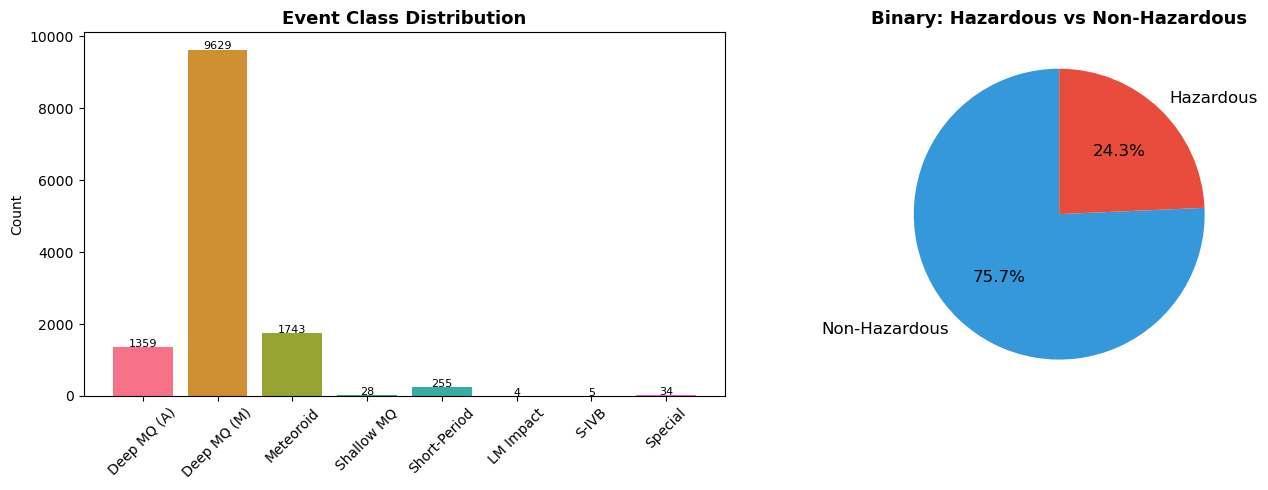

In [7]:
df = df.dropna(subset=['target_label'])
df['target_label'] = df['target_label'].astype(int)

print("Class distribution:")
for k, v in df['target_label'].value_counts().sort_index().items():
    print(f"  {CLASS_NAMES[k]:20s}  {v:5d}  ({v/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['target_label'].value_counts().sort_index()
labels = [CLASS_NAMES[i] for i in counts.index]
colors = sns.color_palette('husl', len(counts))
bars = axes[0].bar(labels, counts.values, color=colors)
axes[0].set_title('Event Class Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+5,
                 str(v), ha='center', fontsize=8)

# Pie chart (binary)
bin_counts = df['target_hazardous'].value_counts()
axes[1].pie(bin_counts.values, labels=['Non-Hazardous','Hazardous'],
            colors=['#3498db','#e74c3c'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize':12})
axes[1].set_title('Binary: Hazardous vs Non-Hazardous', fontweight='bold', fontsize=13)

plt.tight_layout(); plt.show()

## 6. Exploratory Data Analysis

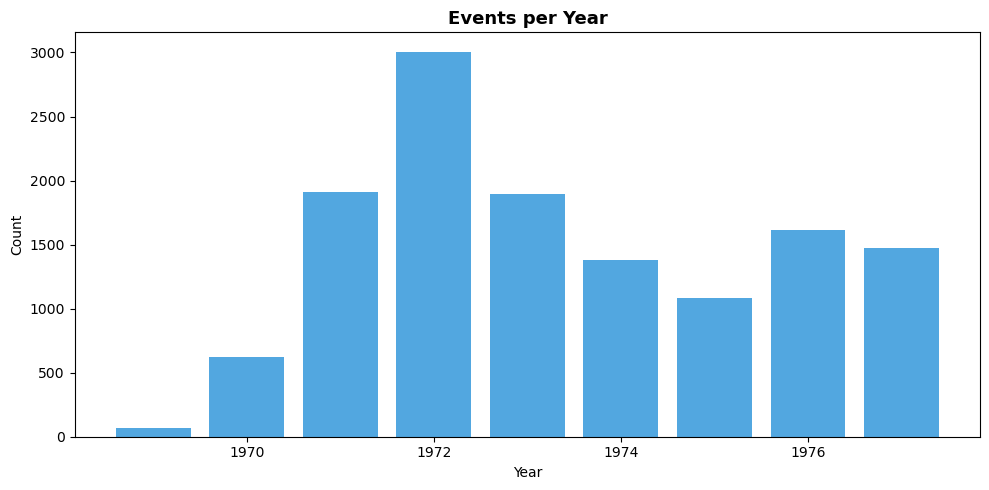

In [29]:
# Plot 1 — Events per Year
fig, ax = plt.subplots(figsize=(10, 5))
yearly = df.groupby('year_full')['target_label'].count()
ax.bar(yearly.index.astype(int), yearly.values, color='#3498db', alpha=0.85)
ax.set_title('Events per Year', fontweight='bold', fontsize=13)
ax.set_xlabel('Year'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

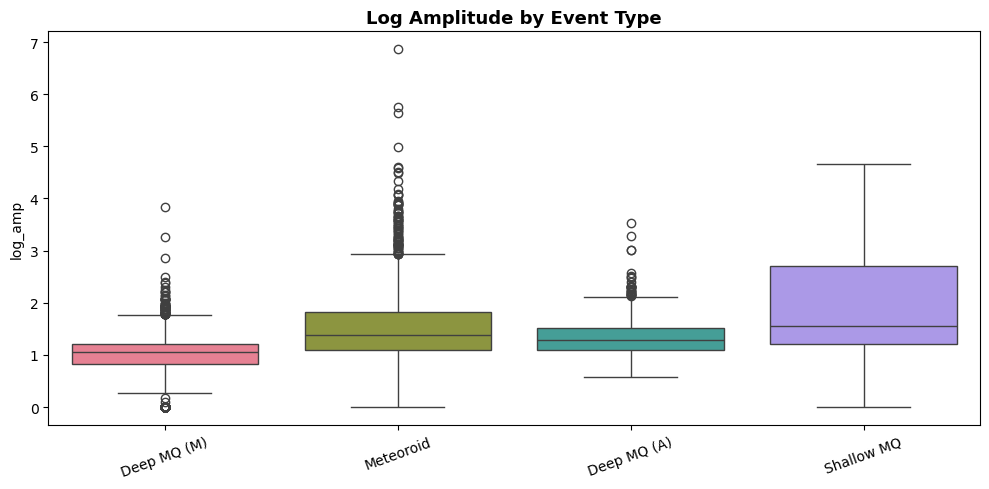

In [30]:
# Plot 2 — Log Amplitude by Event Type
fig, ax = plt.subplots(figsize=(10, 5))
main = df[df['target_label'].isin([0,1,2,3])].copy()
main['label'] = main['target_label'].map(CLASS_NAMES)
main['log_amp'] = np.log1p(main['amp_mean'].clip(lower=0))
sns.boxplot(data=main, x='label', y='log_amp', ax=ax, palette='husl')
ax.set_title('Log Amplitude by Event Type', fontweight='bold', fontsize=13)
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

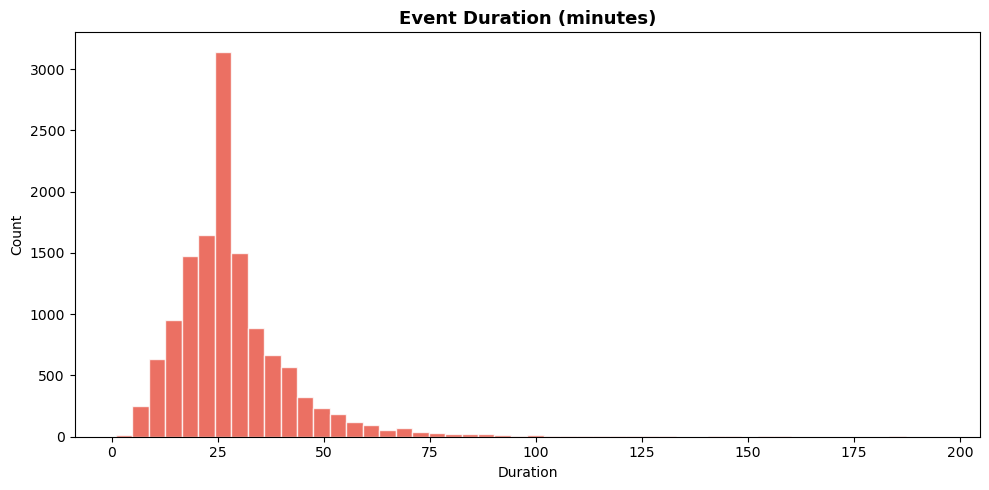

In [31]:
# Plot 3 — Event Duration Distribution
fig, ax = plt.subplots(figsize=(10, 5))
dur = df['duration_min'].dropna()
dur = dur[(dur > 0) & (dur < 200)]
ax.hist(dur, bins=50, color='#e74c3c', alpha=0.8, edgecolor='white')
ax.set_title('Event Duration (minutes)', fontweight='bold', fontsize=13)
ax.set_xlabel('Duration'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

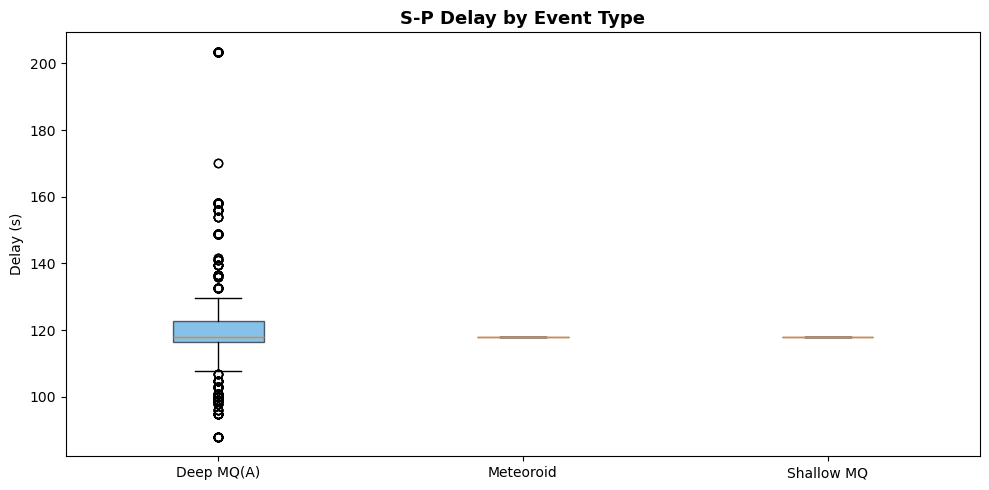

In [32]:
# Plot 4 — S-P Delay by Event Type
fig, ax = plt.subplots(figsize=(10, 5))
sp_data, sp_labels = [], []
for et, lbl in [(0,'Deep MQ(A)'),(2,'Meteoroid'),(3,'Shallow MQ')]:
    vals = df[df['target_label']==et]['sp_delay_mean'].dropna()
    vals = vals[(vals>0)&(vals<400)]
    if len(vals) > 0:
        sp_data.append(vals.values); sp_labels.append(lbl)
if sp_data:
    ax.boxplot(sp_data, labels=sp_labels, patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6))
ax.set_title('S-P Delay by Event Type', fontweight='bold', fontsize=13)
ax.set_ylabel('Delay (s)')
plt.tight_layout(); plt.show()

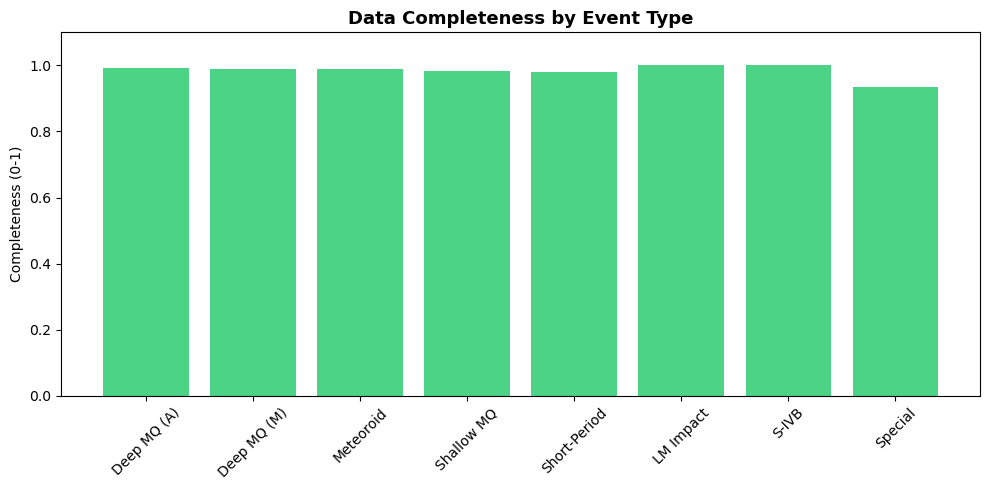

In [33]:
# Plot 5 — Data Completeness by Event Type
fig, ax = plt.subplots(figsize=(10, 5))
comp = df.groupby('target_label')['data_completeness'].mean()
ax.bar([CLASS_NAMES[i] for i in comp.index], comp.values, color='#2ecc71', alpha=0.85)
ax.set_title('Data Completeness by Event Type', fontweight='bold', fontsize=13)
ax.set_ylabel('Completeness (0-1)'); ax.tick_params(axis='x', rotation=45); ax.set_ylim(0, 1.1)
plt.tight_layout(); plt.show()

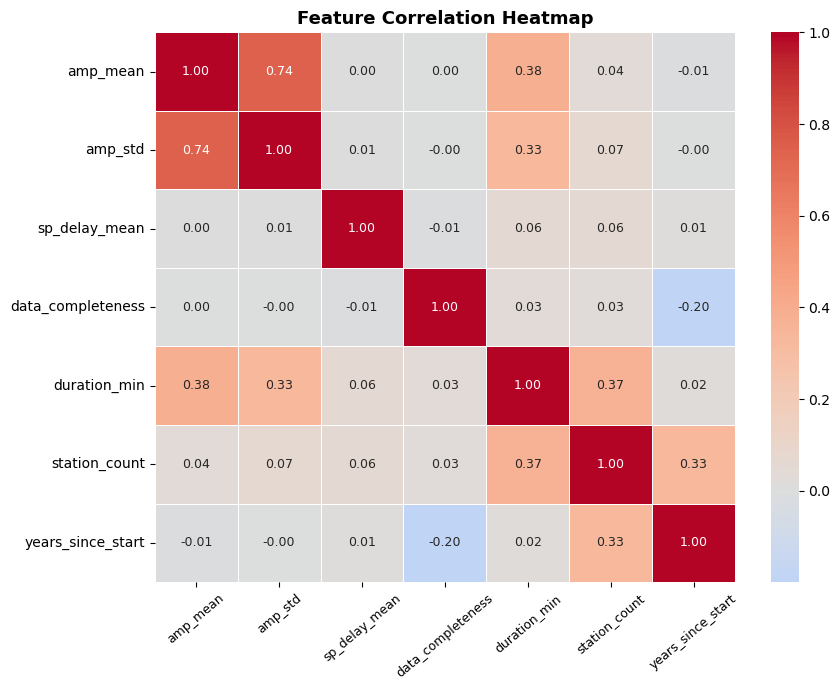

In [34]:
# Plot 6 — Feature Correlation Heatmap
fig, ax = plt.subplots(figsize=(9, 7))
feat_c = ['amp_mean','amp_std','sp_delay_mean','data_completeness',
          'duration_min','station_count','years_since_start']
feat_c = [f for f in feat_c if f in df.columns]
sns.heatmap(df[feat_c].corr(), ax=ax, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size':9}, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=13)
ax.tick_params(axis='x', rotation=40, labelsize=9)
plt.tight_layout(); plt.show()

## 7. VIF Multicollinearity Diagnostics

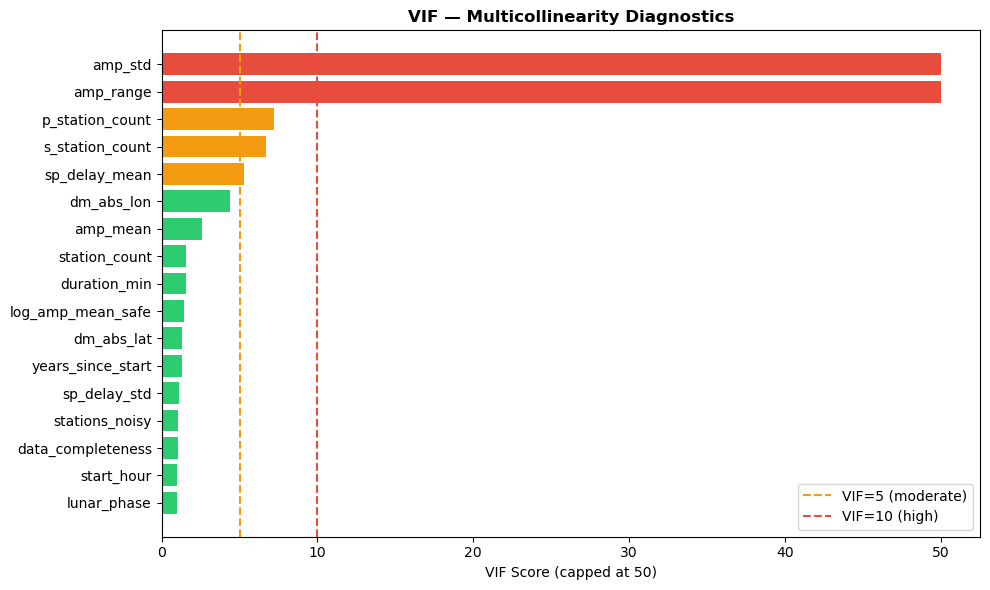

Dropping high-VIF features (>10): ['amp_std', 'amp_range']


In [9]:
def compute_vif(X_df):
    cols = X_df.columns.tolist()
    Xn   = X_df.fillna(0).values
    res  = []
    for i, col in enumerate(cols):
        mask = [j for j in range(len(cols)) if j != i]
        r2   = LinearRegression().fit(Xn[:,mask], Xn[:,i]).score(Xn[:,mask], Xn[:,i])
        res.append({'Feature': col, 'VIF': round(1/(1-r2) if r2<1.0 else np.inf, 2)})
    return pd.DataFrame(res).sort_values('VIF', ascending=False)

vif_subset = ['amp_mean','amp_std','amp_range','log_amp_mean_safe','station_count',
              'sp_delay_mean','sp_delay_std','data_completeness','stations_noisy',
              'duration_min','start_hour','lunar_phase','years_since_start',
              'dm_abs_lat','dm_abs_lon','p_station_count','s_station_count']
vif_subset = [f for f in vif_subset if f in df.columns]
vif_df     = compute_vif(df[vif_subset].apply(pd.to_numeric, errors='coerce'))

fig, ax = plt.subplots(figsize=(10, 6))
cv = ['#e74c3c' if v>10 else '#f39c12' if v>5 else '#2ecc71' for v in vif_df['VIF']]
ax.barh(vif_df['Feature'].values[::-1], np.minimum(vif_df['VIF'].values[::-1],50), color=cv[::-1])
ax.axvline(5,  color='#f39c12', linestyle='--', lw=1.5, label='VIF=5 (moderate)')
ax.axvline(10, color='#e74c3c', linestyle='--', lw=1.5, label='VIF=10 (high)')
ax.set_title('VIF — Multicollinearity Diagnostics', fontweight='bold', fontsize=12)
ax.set_xlabel('VIF Score (capped at 50)'); ax.legend()
plt.tight_layout(); plt.show()

high_vif = vif_df[vif_df['VIF'] > 10]['Feature'].tolist()
print(f"Dropping high-VIF features (>10): {high_vif}")

## 8. Feature & Target Split

In [10]:
# Safe feature list — no ratios, no metadata, no string cols
keep = [
    'amp_mean','amp_max','amp_min','amp_std','amp_range','amp_sum',
    'amp_s12','amp_s14','amp_s15','amp_s16',
    'log_amp_s12_safe','log_amp_s14_safe','log_amp_s15_safe',
    'log_amp_s16_safe','log_amp_mean_safe',
    'station_count','stations_no_data','stations_noisy',
    'stations_good','data_completeness','seismo_available_count',
    'qual_s12','qual_s14','qual_s15','qual_s16','qual_mean','qual_max',
    'sp_delay_s12','sp_delay_s14','sp_delay_s15','sp_delay_s16',
    'sp_delay_mean','sp_delay_std','sp_delay_max',
    'p_station_count','s_station_count','p_arr_spread','s_arr_spread',
    'year_full','day_of_year','lunar_phase','years_since_start',
    'quarter','duration_min','start_hour','event_continues',
    'dm_abs_lat','dm_abs_lon','dm_depth_km','location_uncertainty',
    'waveform_component_count','h_v_ratio',
]
keep = [f for f in keep if f in df.columns]
keep = [f for f in keep if f not in high_vif]

X = df[keep].copy()
y = df['target_label'].copy()
y_bin = df['target_hazardous'].copy()

# Sort chronologically for TimeSeriesSplit
order = df[['year_full','day_of_year']].sort_values(['year_full','day_of_year']).index
X     = X.loc[order].reset_index(drop=True)
y     = y.loc[order].reset_index(drop=True)
y_bin = y_bin.loc[order].reset_index(drop=True)

print(f"Feature matrix : {X.shape}")
print(f"Inf count      : {np.isinf(X.values).sum()}  ✓")
print(f"Features       : {list(X.columns)}")

Feature matrix : (13057, 50)
Inf count      : 0  ✓
Features       : ['amp_mean', 'amp_max', 'amp_min', 'amp_sum', 'amp_s12', 'amp_s14', 'amp_s15', 'amp_s16', 'log_amp_s12_safe', 'log_amp_s14_safe', 'log_amp_s15_safe', 'log_amp_s16_safe', 'log_amp_mean_safe', 'station_count', 'stations_no_data', 'stations_noisy', 'stations_good', 'data_completeness', 'seismo_available_count', 'qual_s12', 'qual_s14', 'qual_s15', 'qual_s16', 'qual_mean', 'qual_max', 'sp_delay_s12', 'sp_delay_s14', 'sp_delay_s15', 'sp_delay_s16', 'sp_delay_mean', 'sp_delay_std', 'sp_delay_max', 'p_station_count', 's_station_count', 'p_arr_spread', 's_arr_spread', 'year_full', 'day_of_year', 'lunar_phase', 'years_since_start', 'quarter', 'duration_min', 'start_hour', 'event_continues', 'dm_abs_lat', 'dm_abs_lon', 'dm_depth_km', 'location_uncertainty', 'waveform_component_count', 'h_v_ratio']


## 9. Train / Test Split (Chronological — No Shuffle)

In [11]:
split_idx = int(len(X) * 0.8)

X_train, X_test     = X.iloc[:split_idx],   X.iloc[split_idx:]
y_train, y_test     = y.iloc[:split_idx],   y.iloc[split_idx:]
y_train_b, y_test_b = y_bin.iloc[:split_idx], y_bin.iloc[split_idx:]

print(f"Train : {X_train.shape[0]:,} samples")
print(f"Test  : {X_test.shape[0]:,} samples")
print(f"Train class dist: {dict(y_train.value_counts().sort_index())}")

Train : 10,445 samples
Test  : 2,612 samples
Train class dist: {0: 1020, 1: 7725, 2: 1436, 3: 27, 4: 204, 5: 4, 6: 5, 7: 24}


## 10. Feature Scaling

In [12]:
# Safety: convert, replace inf, fill NaN
X_train = X_train.apply(pd.to_numeric, errors='coerce').replace([np.inf,-np.inf], np.nan)
X_test  = X_test.apply(pd.to_numeric, errors='coerce').replace([np.inf,-np.inf], np.nan)

print(f"Inf before imputing: {np.isinf(X_train.values).sum()} ✓")

imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_train_prep = scaler.fit_transform(imputer.fit_transform(X_train))
X_test_prep  = scaler.transform(imputer.transform(X_test))

tscv = TimeSeriesSplit(n_splits=5)

assert not np.isinf(X_train_prep).any()
assert not np.isnan(X_train_prep).any()
print(f"Preprocessing complete ✓  —  shape: {X_train_prep.shape}")
print("\nTimeSeriesSplit folds:")
for fold, (tr, val) in enumerate(tscv.split(X_train_prep), 1):
    print(f"  Fold {fold}: Train={len(tr):,}  Val={len(val):,}")

Inf before imputing: 0 ✓
Preprocessing complete ✓  —  shape: (10445, 50)

TimeSeriesSplit folds:
  Fold 1: Train=1,745  Val=1,740
  Fold 2: Train=3,485  Val=1,740
  Fold 3: Train=5,225  Val=1,740
  Fold 4: Train=6,965  Val=1,740
  Fold 5: Train=8,705  Val=1,740


## 11. Naive Baseline

In [13]:
baseline      = DummyClassifier(strategy='stratified', random_state=42)
baseline.fit(X_train_prep, y_train)
baseline_pred = baseline.predict(X_test_prep)

print("Naive Baseline (Stratified — benchmark to beat):")
print(f"  Accuracy      : {accuracy_score(y_test, baseline_pred):.4f}")
print(f"  F1 (weighted) : {f1_score(y_test, baseline_pred, average='weighted', zero_division=0):.4f}")
print(f"  F1 (macro)    : {f1_score(y_test, baseline_pred, average='macro',    zero_division=0):.4f}")

Naive Baseline (Stratified — benchmark to beat):
  Accuracy      : 0.5827
  F1 (weighted) : 0.5769
  F1 (macro)    : 0.1468


## 12. Ridge (L2) Logistic Regression

In [14]:
gs_ridge = GridSearchCV(
    LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000,
                       class_weight='balanced', random_state=42),
    {'C': [0.01, 0.1, 1.0, 10.0]}, cv=tscv, scoring='f1_weighted', n_jobs=-1)
gs_ridge.fit(X_train_prep, y_train)
best_ridge = gs_ridge.best_estimator_
pred_ridge = best_ridge.predict(X_test_prep)

print(f"Best C : {gs_ridge.best_params_['C']}")
print(f"Accuracy      : {accuracy_score(y_test, pred_ridge):.4f}")
print(f"F1 (weighted) : {f1_score(y_test, pred_ridge, average='weighted', zero_division=0):.4f}")
print(f"F1 (macro)    : {f1_score(y_test, pred_ridge, average='macro', zero_division=0):.4f}")
print()
print(classification_report(y_test, pred_ridge,
      target_names=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES)],
      labels=sorted(CLASS_NAMES.keys()), zero_division=0))

Best C : 10.0
Accuracy      : 0.3928
F1 (weighted) : 0.4714
F1 (macro)    : 0.3132

              precision    recall  f1-score   support

 Deep MQ (A)       0.98      0.73      0.84       339
 Deep MQ (M)       0.94      0.30      0.45      1904
   Meteoroid       0.15      0.58      0.24       307
  Shallow MQ       0.00      0.00      0.00         1
Short-Period       0.23      0.71      0.35        51
   LM Impact       0.00      0.00      0.00         0
       S-IVB       0.00      0.00      0.00         0
     Special       0.00      0.00      0.00        10

    accuracy                           0.39      2612
   macro avg       0.29      0.29      0.23      2612
weighted avg       0.83      0.39      0.47      2612



## 13. Lasso (L1) Logistic Regression

In [15]:
gs_lasso = GridSearchCV(
    LogisticRegression(penalty='l1', solver='saga', max_iter=2000,
                       class_weight='balanced', random_state=42),
    {'C': [0.01, 0.1, 1.0, 10.0]}, cv=tscv, scoring='f1_weighted', n_jobs=-1)
gs_lasso.fit(X_train_prep, y_train)
best_lasso = gs_lasso.best_estimator_
pred_lasso = best_lasso.predict(X_test_prep)

n_zero = (best_lasso.coef_ == 0).sum()
print(f"Best C              : {gs_lasso.best_params_['C']}")
print(f"Zeroed features (L1): {n_zero} / {X_train_prep.shape[1]}")
print(f"Accuracy            : {accuracy_score(y_test, pred_lasso):.4f}")
print(f"F1 (weighted)       : {f1_score(y_test, pred_lasso, average='weighted', zero_division=0):.4f}")
print(f"F1 (macro)          : {f1_score(y_test, pred_lasso, average='macro', zero_division=0):.4f}")
print()
print(classification_report(y_test, pred_lasso,
      target_names=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES)],
      labels=sorted(CLASS_NAMES.keys()), zero_division=0))

Best C              : 0.01
Zeroed features (L1): 327 / 50
Accuracy            : 0.3580
F1 (weighted)       : 0.4440
F1 (macro)          : 0.2297

              precision    recall  f1-score   support

 Deep MQ (A)       1.00      0.73      0.85       339
 Deep MQ (M)       0.95      0.27      0.41      1904
   Meteoroid       0.15      0.43      0.22       307
  Shallow MQ       0.00      1.00      0.01         1
Short-Period       0.20      0.88      0.33        51
   LM Impact       0.00      0.00      0.00         0
       S-IVB       0.00      0.00      0.00         0
     Special       0.01      0.40      0.02        10

    accuracy                           0.36      2612
   macro avg       0.29      0.46      0.23      2612
weighted avg       0.84      0.36      0.44      2612



## 14. Random Forest

In [16]:
gs_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    {'n_estimators':[200,400],'max_depth':[10,20,None],'min_samples_split':[2,5]},
    cv=tscv, scoring='f1_weighted', n_jobs=-1)
gs_rf.fit(X_train_prep, y_train)
best_rf = gs_rf.best_estimator_
pred_rf = best_rf.predict(X_test_prep)

print(f"Best params   : {gs_rf.best_params_}")
print(f"Accuracy      : {accuracy_score(y_test, pred_rf):.4f}")
print(f"F1 (weighted) : {f1_score(y_test, pred_rf, average='weighted', zero_division=0):.4f}")
print(f"F1 (macro)    : {f1_score(y_test, pred_rf, average='macro', zero_division=0):.4f}")
print()
print(classification_report(y_test, pred_rf,
      target_names=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES)],
      labels=sorted(CLASS_NAMES.keys()), zero_division=0))

Best params   : {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 400}
Accuracy      : 0.8740
F1 (weighted) : 0.8672
F1 (macro)    : 0.4993

              precision    recall  f1-score   support

 Deep MQ (A)       1.00      0.73      0.85       339
 Deep MQ (M)       0.89      0.96      0.93      1904
   Meteoroid       0.67      0.54      0.60       307
  Shallow MQ       0.00      0.00      0.00         1
Short-Period       0.67      0.59      0.62        51
   LM Impact       0.00      0.00      0.00         0
       S-IVB       0.00      0.00      0.00         0
     Special       0.00      0.00      0.00        10

    accuracy                           0.87      2612
   macro avg       0.40      0.35      0.37      2612
weighted avg       0.87      0.87      0.87      2612



## 15. Gradient Boosting

In [17]:
gs_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {'n_estimators':[100,200],'learning_rate':[0.05,0.1],'max_depth':[3,5]},
    cv=tscv, scoring='f1_weighted', n_jobs=-1)
gs_gb.fit(X_train_prep, y_train)
best_gb = gs_gb.best_estimator_
pred_gb = best_gb.predict(X_test_prep)

print(f"Best params   : {gs_gb.best_params_}")
print(f"Accuracy      : {accuracy_score(y_test, pred_gb):.4f}")
print(f"F1 (weighted) : {f1_score(y_test, pred_gb, average='weighted', zero_division=0):.4f}")
print(f"F1 (macro)    : {f1_score(y_test, pred_gb, average='macro', zero_division=0):.4f}")
print()
print(classification_report(y_test, pred_gb,
      target_names=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES)],
      labels=sorted(CLASS_NAMES.keys()), zero_division=0))

Best params   : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Accuracy      : 0.8783
F1 (weighted) : 0.8711
F1 (macro)    : 0.5359

              precision    recall  f1-score   support

 Deep MQ (A)       0.99      0.73      0.84       339
 Deep MQ (M)       0.89      0.97      0.93      1904
   Meteoroid       0.74      0.54      0.62       307
  Shallow MQ       0.00      0.00      0.00         1
Short-Period       0.67      0.55      0.60        51
   LM Impact       0.00      0.00      0.00         0
       S-IVB       0.00      0.00      0.00         0
     Special       0.25      0.20      0.22        10

    accuracy                           0.88      2612
   macro avg       0.44      0.37      0.40      2612
weighted avg       0.88      0.88      0.87      2612



## 16. Model Comparison

In [18]:
model_names = ['Baseline','Ridge (L2)','Lasso (L1)','Random Forest','Gradient Boosting']
all_preds   = [baseline_pred, pred_ridge, pred_lasso, pred_rf, pred_gb]
all_models  = [baseline, best_ridge, best_lasso, best_rf, best_gb]
COLORS      = ['#95a5a6','#3498db','#e74c3c','#2ecc71','#f39c12']

results = []
for name, pred, model in zip(model_names, all_preds, all_models):
    try:
        prob    = model.predict_proba(X_test_prep)
        auc_val = roc_auc_score(y_test, prob, multi_class='ovr',
                                average='weighted', labels=np.unique(y_test))
    except: auc_val = np.nan
    results.append({
        'Model'        : name,
        'Accuracy'     : round(accuracy_score(y_test, pred), 4),
        'Precision (W)': round(precision_score(y_test, pred, average='weighted', zero_division=0), 4),
        'Recall (W)'   : round(recall_score(y_test, pred,    average='weighted', zero_division=0), 4),
        'F1 (Weighted)': round(f1_score(y_test, pred,        average='weighted', zero_division=0), 4),
        'F1 (Macro)'   : round(f1_score(y_test, pred,        average='macro',    zero_division=0), 4),
        'ROC-AUC'      : round(auc_val, 4) if not np.isnan(auc_val) else 'N/A',
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model  Accuracy  Precision (W)  Recall (W)  F1 (Weighted)  F1 (Macro) ROC-AUC
         Baseline    0.5827         0.5725      0.5827         0.5769      0.1468     N/A
       Ridge (L2)    0.3928         0.8313      0.3928         0.4714      0.3132     N/A
       Lasso (L1)    0.3580         0.8411      0.3580         0.4440      0.2297     N/A
    Random Forest    0.8740         0.8693      0.8740         0.8672      0.4993     N/A
Gradient Boosting    0.8783         0.8758      0.8783         0.8711      0.5359     N/A


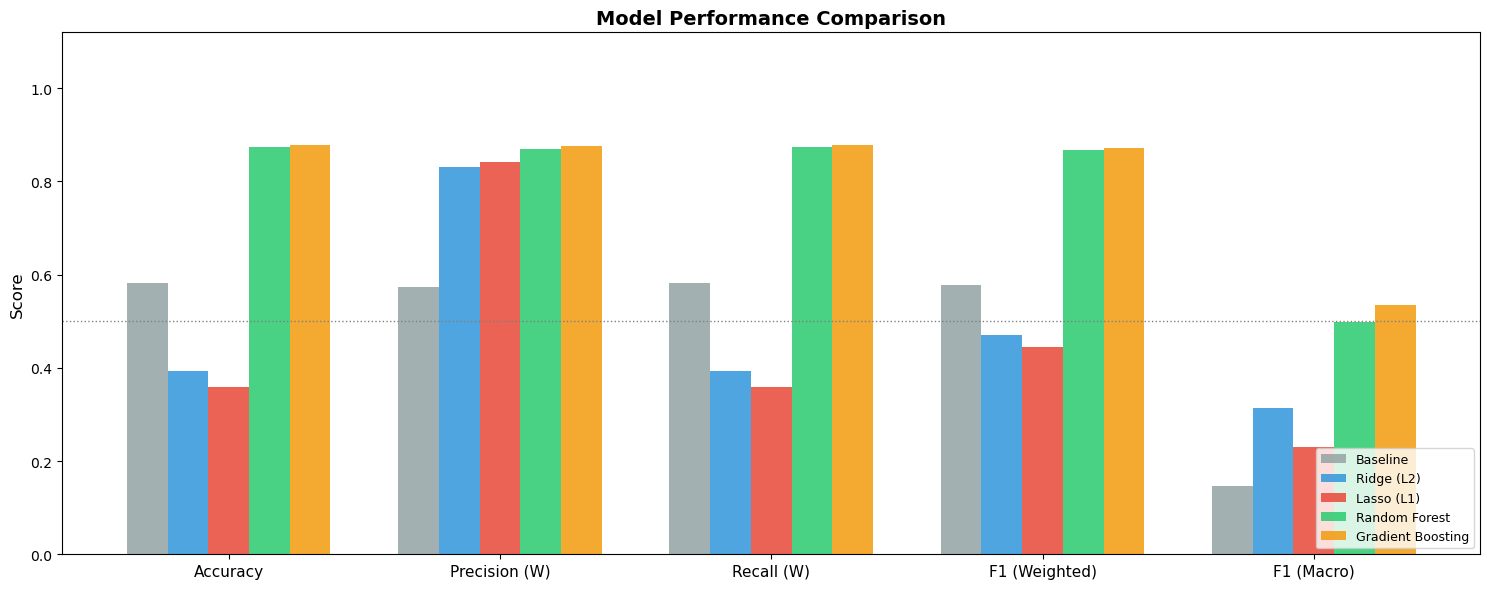

In [19]:
metrics = ['Accuracy','Precision (W)','Recall (W)','F1 (Weighted)','F1 (Macro)']
x, w = np.arange(len(metrics)), 0.15
fig, ax = plt.subplots(figsize=(15, 6))
for i, (name, color) in enumerate(zip(model_names, COLORS)):
    row  = results_df[results_df['Model']==name].iloc[0]
    vals = [row[m] for m in metrics]
    ax.bar(x + i*w, vals, w, label=name, color=color, alpha=0.87)
ax.set_xticks(x + w*2); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.legend(fontsize=9, loc='lower right')
ax.axhline(0.5, color='grey', linestyle=':', lw=1)
plt.tight_layout(); plt.show()

## 17. Confusion Matrices

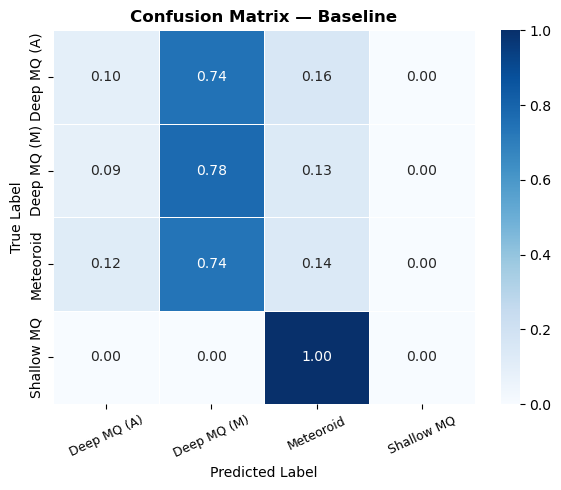

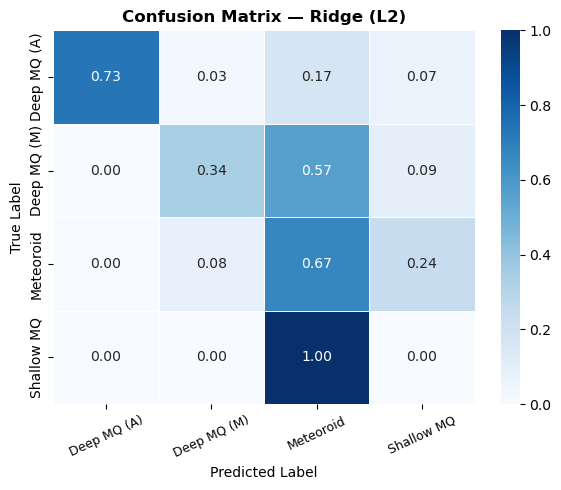

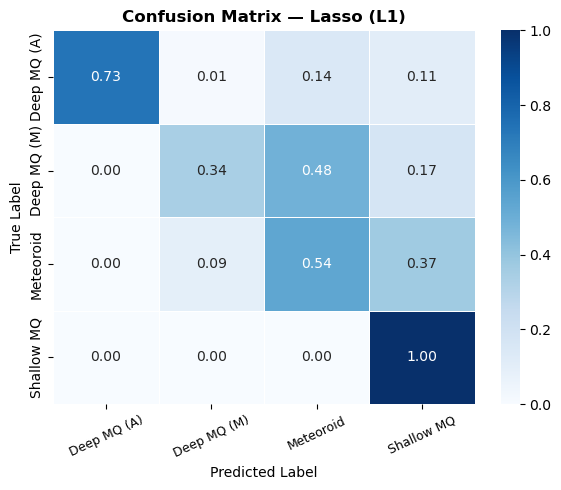

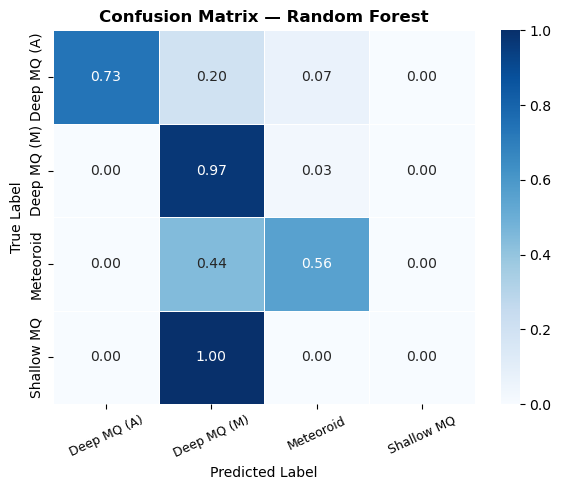

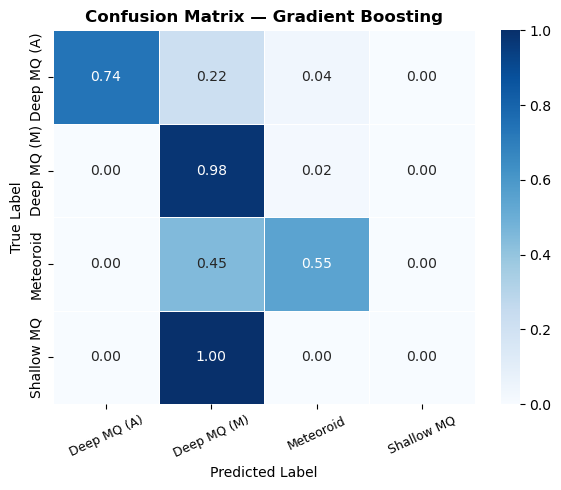

In [36]:
main_classes = [0,1,2,3]
main_labels  = [CLASS_NAMES[c] for c in main_classes]
mask = y_test.isin(main_classes)

for name, pred in zip(model_names, all_preds):
    pred_m = np.array(pred)[mask.values]
    y_m    = y_test[mask].values
    cm     = confusion_matrix(y_m, pred_m, labels=main_classes).astype(float)
    rs     = cm.sum(axis=1, keepdims=True)
    cm_n   = np.divide(cm, rs, where=rs!=0)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=main_labels, yticklabels=main_labels,
                ax=ax, linewidths=0.5, vmin=0, vmax=1)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold', fontsize=12)
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=25, labelsize=9)
    plt.tight_layout(); plt.show()

## 18. ROC Curves — Binary Hazard Detection

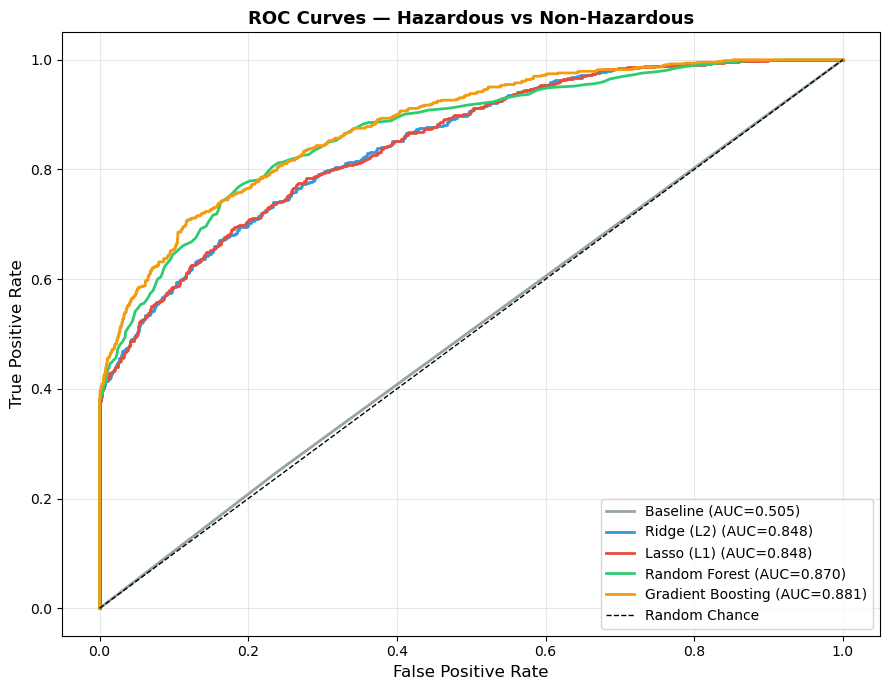

In [21]:
fig, ax = plt.subplots(figsize=(9, 7))
binary_clfs = {
    'Baseline'         : DummyClassifier(strategy='stratified', random_state=42),
    'Ridge (L2)'       : LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000,
                           class_weight='balanced', random_state=42),
    'Lasso (L1)'       : LogisticRegression(penalty='l1', solver='saga', max_iter=2000,
                           class_weight='balanced', random_state=42),
    'Random Forest'    : RandomForestClassifier(n_estimators=200, class_weight='balanced',
                           random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}
for (name, clf), color in zip(binary_clfs.items(), COLORS):
    clf.fit(X_train_prep, y_train_b)
    score = clf.predict_proba(X_test_prep)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_b, score)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random Chance')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — Hazardous vs Non-Hazardous', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 19. TimeSeriesSplit Cross-Validation Stability

Baseline                acc=0.5930±0.0399  f1_w=0.5920
Ridge (L2)              acc=0.6108±0.1090  f1_w=0.6640
Lasso (L1)              acc=0.5308±0.1379  f1_w=0.6085
Random Forest           acc=0.8797±0.0431  f1_w=0.8659
Gradient Boosting       acc=0.8766±0.0514  f1_w=0.8663


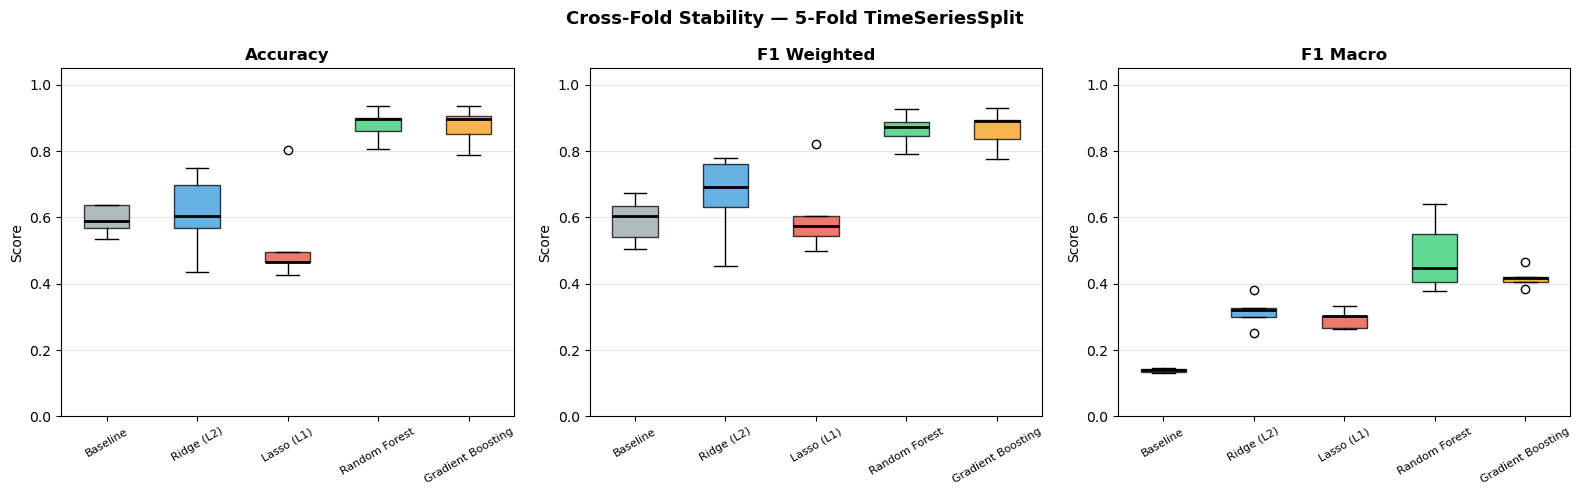

In [23]:
cv_results = {}
for name, model in zip(model_names, all_models):
    cv_res = cross_validate(model, X_train_prep, y_train, cv=tscv,
                            scoring=['accuracy','f1_weighted','f1_macro'],
                            return_train_score=True, n_jobs=-1)
    cv_results[name] = cv_res
    print(f"{name:22s}  acc={cv_res['test_accuracy'].mean():.4f}±{cv_res['test_accuracy'].std():.4f}"
          f"  f1_w={cv_res['test_f1_weighted'].mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax_i, metric in enumerate(['test_accuracy','test_f1_weighted','test_f1_macro']):
    ax   = axes[ax_i]
    data = [cv_results[n][metric] for n in model_names]
    bp   = ax.boxplot(data, labels=model_names, patch_artist=True,
                      medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_title(metric.replace('test_','').replace('_',' ').title(), fontweight='bold')
    ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(True, axis='y', alpha=0.3)
plt.suptitle('Cross-Fold Stability — 5-Fold TimeSeriesSplit', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 20. Bias-Variance Analysis — Learning Curves

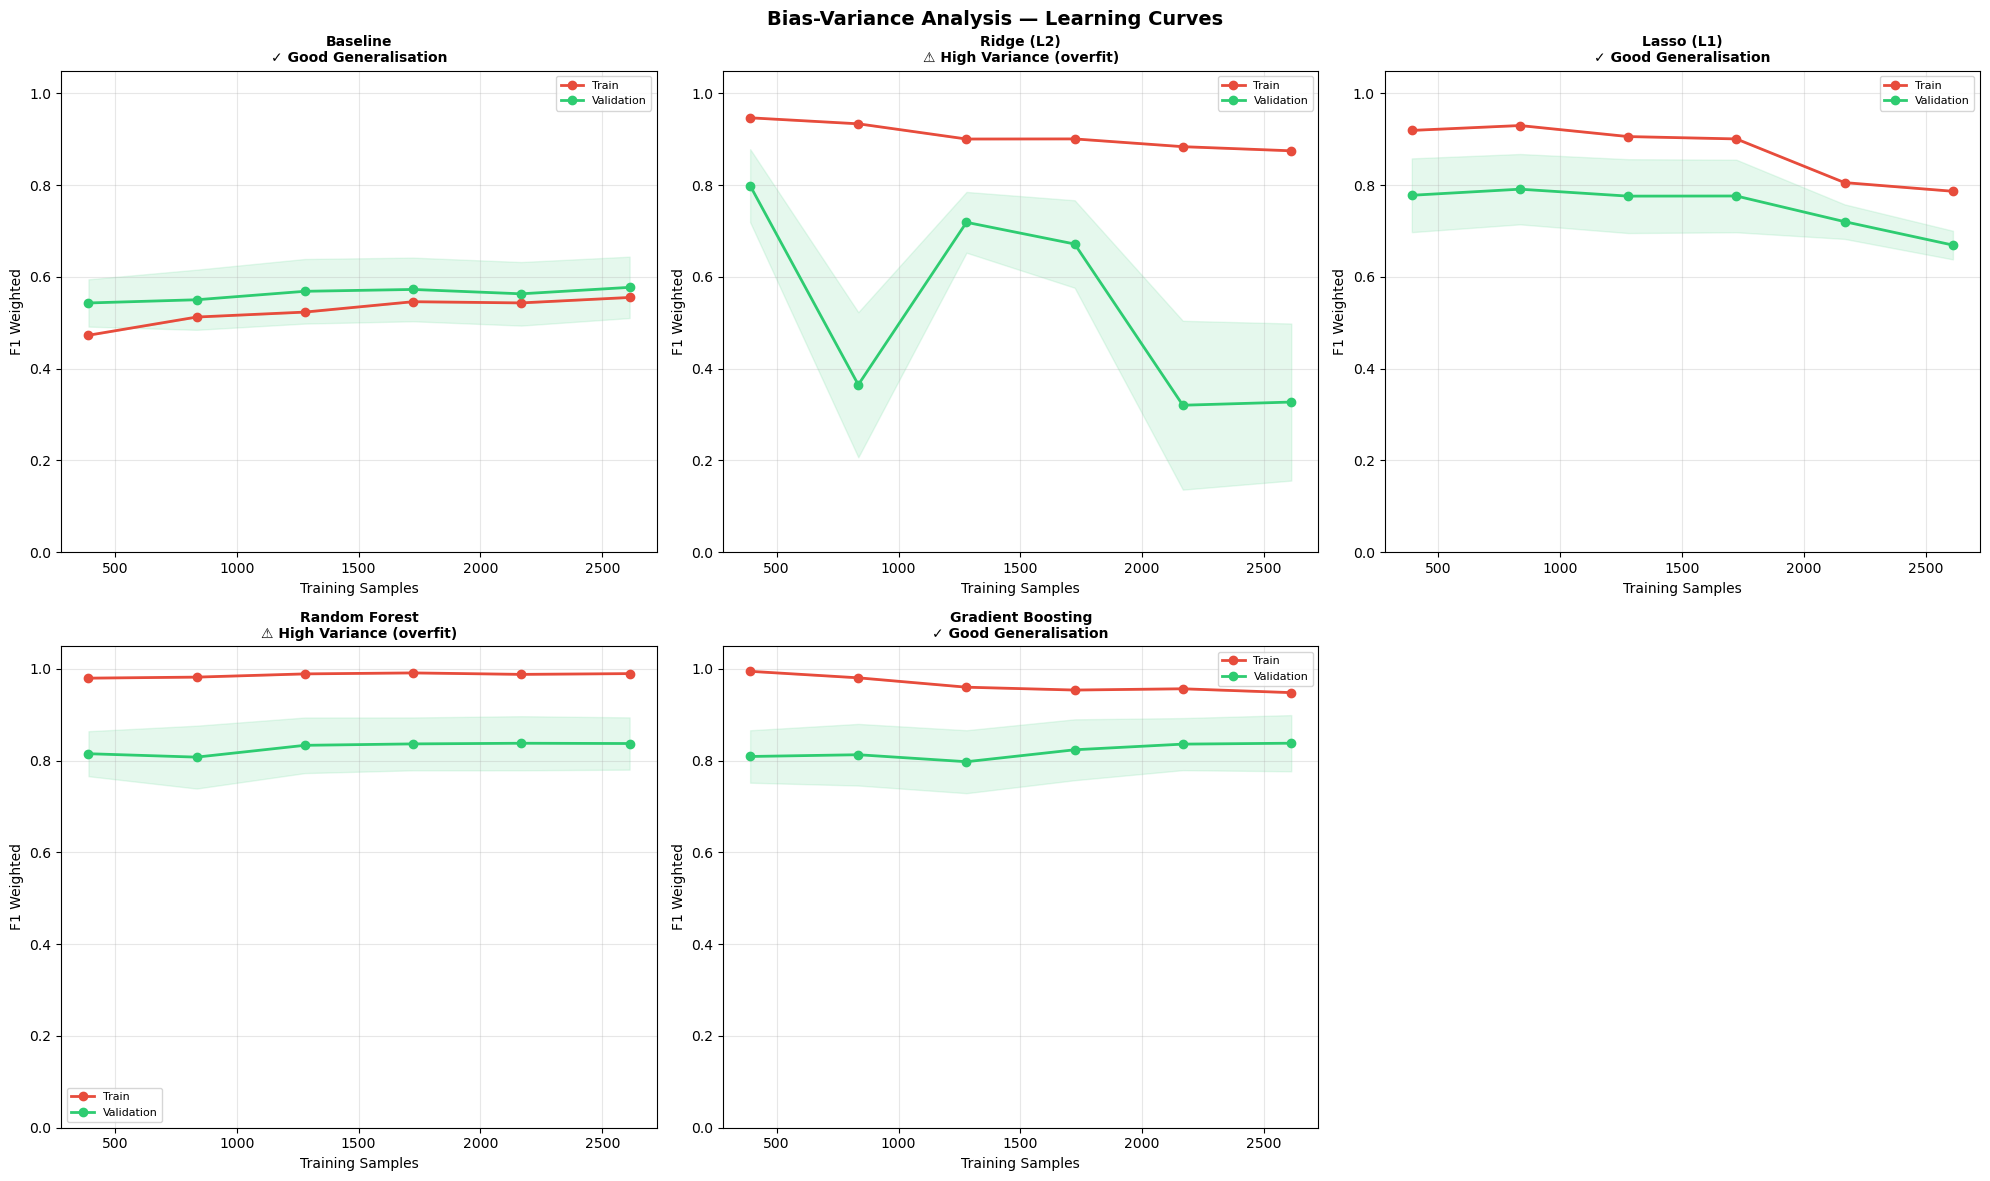

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
for idx, (name, model) in enumerate(zip(model_names, all_models)):
    ax = axes[idx]
    train_sizes, train_sc, val_sc = learning_curve(
        model, X_train_prep, y_train,
        train_sizes=np.linspace(0.15, 1.0, 6),
        cv=TimeSeriesSplit(n_splits=3), scoring='f1_weighted', n_jobs=-1)
    t_m, t_s = train_sc.mean(1), train_sc.std(1)
    v_m, v_s = val_sc.mean(1),   val_sc.std(1)
    ax.plot(train_sizes, t_m, 'o-', color='#e74c3c', lw=2, label='Train')
    ax.plot(train_sizes, v_m, 'o-', color='#2ecc71', lw=2, label='Validation')
    ax.fill_between(train_sizes, t_m-t_s, t_m+t_s, alpha=0.12, color='#e74c3c')
    ax.fill_between(train_sizes, v_m-v_s, v_m+v_s, alpha=0.12, color='#2ecc71')
    gap  = t_m[-1] - v_m[-1]
    note = ('⚠ High Variance (overfit)' if gap>0.15 else
            '⚠ High Bias (underfit)' if v_m[-1]<0.4 else '✓ Good Generalisation')
    ax.set_title(f'{name}\n{note}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Training Samples'); ax.set_ylabel('F1 Weighted')
    ax.legend(fontsize=8); ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)
axes[-1].axis('off')
plt.suptitle('Bias-Variance Analysis — Learning Curves', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 21. Feature Importance & Coefficient Analysis

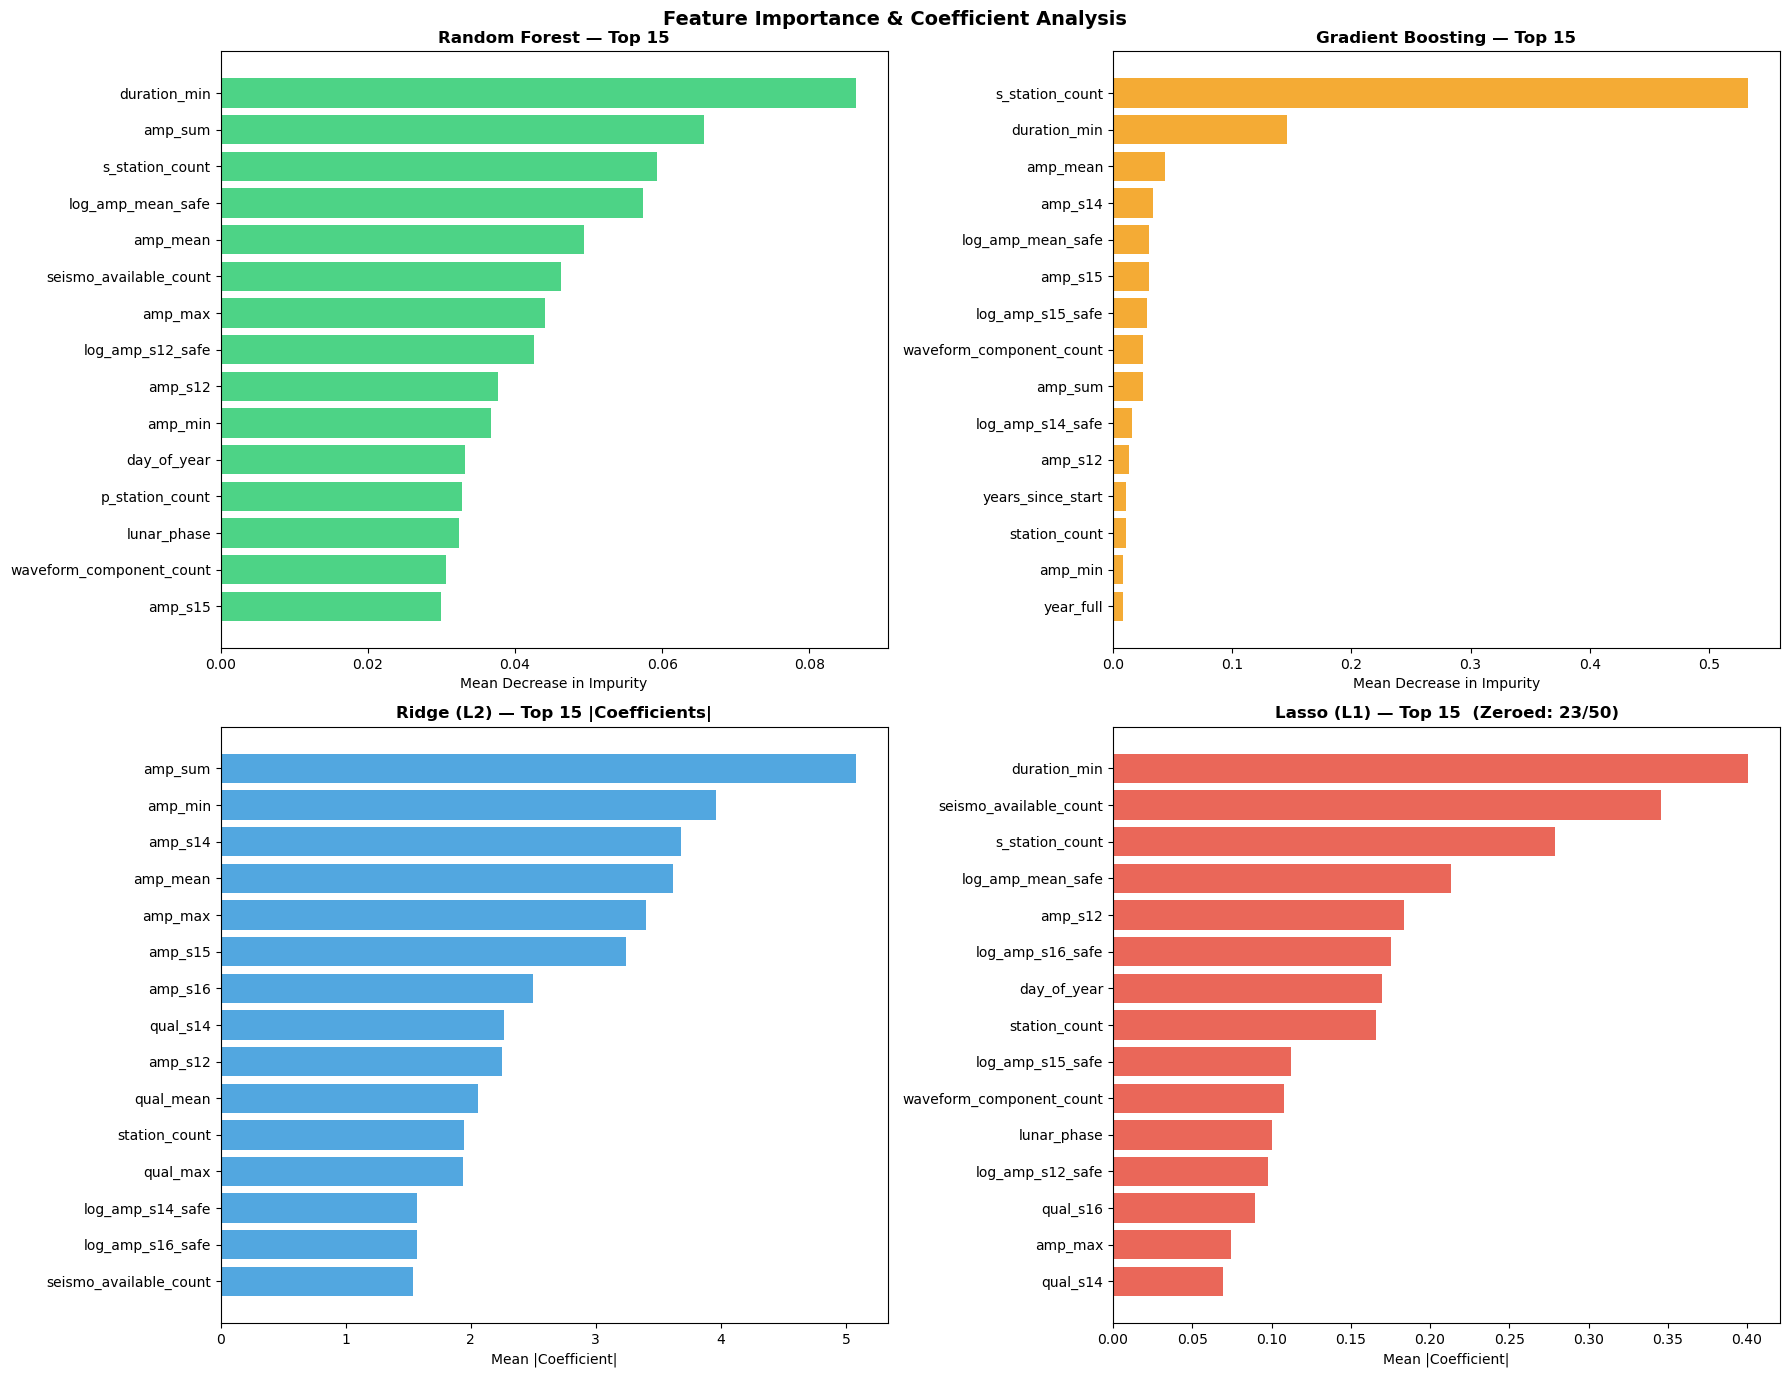

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()  # ← add this line
TOP_N = 15

rf_imp = pd.DataFrame({'Feature':X.columns,'Importance':best_rf.feature_importances_}
                      ).sort_values('Importance', ascending=True).tail(TOP_N)
axes[0].barh(rf_imp['Feature'], rf_imp['Importance'], color='#2ecc71', alpha=0.85)
axes[0].set_title(f'Random Forest — Top {TOP_N}', fontweight='bold')
axes[0].set_xlabel('Mean Decrease in Impurity')

gb_imp = pd.DataFrame({'Feature':X.columns,'Importance':best_gb.feature_importances_}
                      ).sort_values('Importance', ascending=True).tail(TOP_N)
axes[1].barh(gb_imp['Feature'], gb_imp['Importance'], color='#f39c12', alpha=0.85)
axes[1].set_title(f'Gradient Boosting — Top {TOP_N}', fontweight='bold')
axes[1].set_xlabel('Mean Decrease in Impurity')

ridge_coef = np.abs(best_ridge.coef_).mean(axis=0)
r_imp = pd.DataFrame({'Feature':X.columns,'AbsCoef':ridge_coef}
                     ).sort_values('AbsCoef', ascending=True).tail(TOP_N)
axes[2].barh(r_imp['Feature'], r_imp['AbsCoef'], color='#3498db', alpha=0.85)
axes[2].set_title(f'Ridge (L2) — Top {TOP_N} |Coefficients|', fontweight='bold')
axes[2].set_xlabel('Mean |Coefficient|')

lasso_coef = np.abs(best_lasso.coef_).mean(axis=0)
n_zero = (lasso_coef == 0).sum()
l_imp = pd.DataFrame({'Feature':X.columns,'AbsCoef':lasso_coef}
                     ).sort_values('AbsCoef', ascending=True).tail(TOP_N)
axes[3].barh(l_imp['Feature'], l_imp['AbsCoef'], color='#e74c3c', alpha=0.85)
axes[3].set_title(f'Lasso (L1) — Top {TOP_N}  (Zeroed: {n_zero}/{len(X.columns)})', fontweight='bold')
axes[3].set_xlabel('Mean |Coefficient|')

plt.suptitle('Feature Importance & Coefficient Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 22. Final Summary

In [27]:
print("="*65)
print("  FINAL MODEL COMPARISON")
print("="*65)
print(results_df.to_string(index=False))

best_name = results_df.loc[results_df['F1 (Weighted)'].idxmax(), 'Model']
best_f1   = results_df['F1 (Weighted)'].max()
base_f1   = results_df.loc[results_df['Model']=='Baseline','F1 (Weighted)'].values[0]
print(f"\n  Best model         : {best_name}")
print(f"  Best F1 (Weighted) : {best_f1:.4f}")
print(f"  Gain over baseline : +{best_f1 - base_f1:.4f}")

  FINAL MODEL COMPARISON
            Model  Accuracy  Precision (W)  Recall (W)  F1 (Weighted)  F1 (Macro) ROC-AUC
         Baseline    0.5827         0.5725      0.5827         0.5769      0.1468     N/A
       Ridge (L2)    0.3928         0.8313      0.3928         0.4714      0.3132     N/A
       Lasso (L1)    0.3580         0.8411      0.3580         0.4440      0.2297     N/A
    Random Forest    0.8740         0.8693      0.8740         0.8672      0.4993     N/A
Gradient Boosting    0.8783         0.8758      0.8783         0.8711      0.5359     N/A

  Best model         : Gradient Boosting
  Best F1 (Weighted) : 0.8711
  Gain over baseline : +0.2942


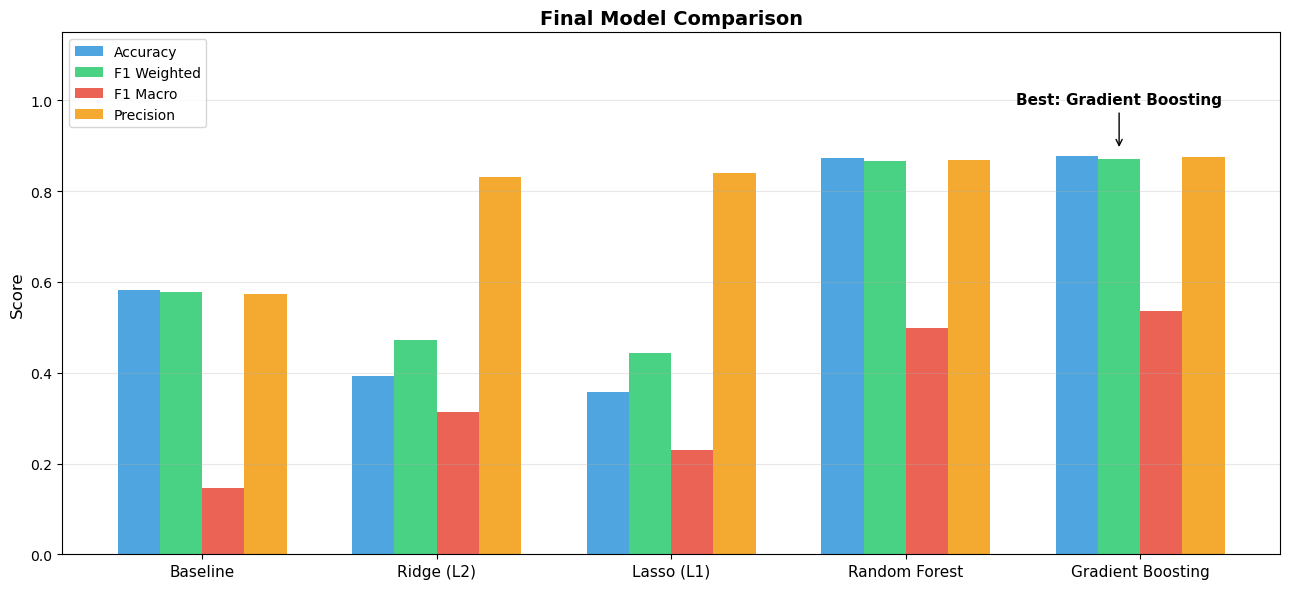

In [28]:
fig, ax = plt.subplots(figsize=(13, 6))
x, w = np.arange(len(results_df)), 0.18
ax.bar(x-w,   results_df['Accuracy'],       w, label='Accuracy',    color='#3498db', alpha=0.87)
ax.bar(x,     results_df['F1 (Weighted)'],  w, label='F1 Weighted', color='#2ecc71', alpha=0.87)
ax.bar(x+w,   results_df['F1 (Macro)'],     w, label='F1 Macro',    color='#e74c3c', alpha=0.87)
ax.bar(x+2*w, results_df['Precision (W)'],  w, label='Precision',   color='#f39c12', alpha=0.87)
ax.set_xticks(x+w/2); ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Final Model Comparison', fontweight='bold', fontsize=14)
ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.3)
best_idx = results_df['F1 (Weighted)'].idxmax()
ax.annotate(f'Best: {results_df.loc[best_idx,"Model"]}',
            xy=(best_idx, results_df.loc[best_idx,'F1 (Weighted)']+0.02),
            xytext=(best_idx, results_df.loc[best_idx,'F1 (Weighted)']+0.12),
            ha='center', fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'))
plt.tight_layout(); plt.show()
results_df.to_csv('model_comparison_results.csv', index=False)
